In [163]:
%matplotlib inline

import os

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=32"
os.environ["OMP_NUM_THREADS"] = "32"
os.environ["MKL_NUM_THREADS"] = "32"
os.environ["NUMEXPR_NUM_THREADS"] = "32"
os.environ["OPENBLAS_NUM_THREADS"] = "32"
os.environ["VECLIB_MAXIMUM_THREADS"] = "32"
os.environ["NUMBA_NUM_THREADS"] = "32"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"


import numpyro

numpyro.set_host_device_count(30)
import jax 
jax.config.update("jax_enable_x64", True)

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value

import scipy.stats as st
from scipy.optimize import minimize

from scipy.special import erf, gamma, gammainc
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid, cumulative_trapezoid

#import emcee
#import corner

In [164]:
df = pd.read_csv(f'data/s82_multiband_fitted_sdss_small_allbands.csv', index_col=0)
print("Loaded total of: ", len(df))

def split_log_sigma(d, key):
    try:
        log_sigma = np.array(d[key].strip('[]').split(), dtype=float)
        d[f'{key}_1'], d[f'{key}_2'], d[f'{key}_3'] = log_sigma[0], log_sigma[1], log_sigma[2]
    except:
        d[f'{key}_1'], d[f'{key}_2'], d[f'{key}_3'] = np.nan, np.nan, np.nan
    return d

#df = df.apply(partial(split_log_sigma, key='log_sigma_band'), axis=1)
#df = df.apply(partial(split_log_sigma, key='log_sigma_band_err'), axis=1)
df = df.apply(partial(split_log_sigma, key='log_jitter'), axis=1)
df = df.apply(partial(split_log_sigma, key='magerrs_mean'), axis=1)

df = df.drop(columns=['log_jitter', 'magerrs_mean'])

#hdul = fits.open('../../../dr16q_prop_May16_2023.fits')
hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

def populate_sdss_fields(d):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(i)
        # If the SDSS name is not found in the fits data, return the original dictionary
        return d
    i = i[0]
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['z_sys_lines'] = fits_data['ZSYS_LINES'][i]
    d['z_sys_lines_err'] = fits_data['ZSYS_LINES_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 21.85
    d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
    d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
    d['fhost_5100'] = fits_data['FHOST_5100'][i]
    return d

print("a: ", len(df))
df = df.apply(populate_sdss_fields, axis=1)
df = df.dropna(subset=['apparent_mag_i', 'M_i'])
print("b: ", len(df))

def calc_lam_RF(d):
    lam_pivot = {
        'V': 5477,  # Johnson (no direct SDSS equivalent)
        'B': 4353,  # Johnson (no direct SDSS equivalent)
        'R': 6580,  # SDSS r-band
        'g': 4770,  # SDSS g-band
        'r': 6231,  # SDSS r-band
        'i': 7625,  # SDSS i-band
        'z': 9134,  # SDSS z-band
        'u': 3543,  # SDSS u-band
        'y': 9633,  # PS1 y-band
        'TESS': 7865,  # TESS broadband filter
        'kepler': 6420,  # Kepler broadband filter
        '5100 AA': 5100  # Reference wavelength
    }
    # Compute rest-frame wavelength
    lam_pivots = lam_pivot['i']
    lam_RF = lam_pivots / (1 + d['z'])
    d['log_lambda_RF'] = np.log10(lam_RF)
    return d

df = df.apply(calc_lam_RF, axis=1)
df_all = df.copy()

# Remove infinite values from numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(~np.isinf(df[numeric_cols]), np.nan)
df = df.dropna()

print("c: ", len(df))

# for band in [1,2,3]:
#     df = df[(10**df[f'log_sigma_band_{band}']) > np.sqrt(df[f'magerrs_mean_{band}']**2 + (10**df[f'log_jitter_{band}'])**2)]

print(len(df))
df.head()
#df.keys()
#df.columns[df.isna().any()]
#df['log_sigma_band']

Loaded total of:  1001
a:  1001


/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_89745/886846019.py:41: RuntimeWarning: invalid value encountered in log10
  d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_89745/886846019.py:39: RuntimeWarning: invalid value encountered in log10
  d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 21.85
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_89745/886846019.py:40: RuntimeWarning: invalid value encountered in sqrt
  d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_89745/886846019.py:41: RuntimeWarning: invalid value encountered in log10
  d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_89745/886846019.py:41: RuntimeWa

b:  994
c:  980
980


,ra,dec,z,sdss_name,log_lbol,log_lbol_err,log_mbh,log_mbh_err,log_ledd_ratio,log_ledd_ratio_err,...,magerrs_mean_3,z_sys_lines,z_sys_lines_err,ebv,M_i,apparent_mag_i,apparent_mag_i_err,color,fhost_5100,log_lambda_RF
object_id,,,,,,,,,,,,,,,,,,,,,
1438965,4.838463,-0.003156,0.936298,001921.23-000011.3,45.771222,0.007486,8.818842,0.073635,-1.161563,0.074014,...,0.079705,"[0.0, 0.0, 0.0, 0.0, 0.9362982680611558, 0.0, ...","[-1.0, -1.0, -1.0, -1.0, 0.002040060218515557,...",0.020835,-24.488246,19.022315,0.025847,1.347781,0.0,3.595268
1438971,4.833860,-0.377080,2.151229,001920.12-002237.4,46.265064,0.021045,9.172693,0.217707,-1.021572,0.218722,...,0.090612,"[0.0, 0.0, 0.0, 0.0, 2.1509756308922916, 0.0, ...","[-1.0, -1.0, -1.0, -1.0, 0.0021546748681942796...",0.023482,-26.030396,19.361718,0.037808,0.563349,0.0,3.383760
1438975,4.830463,1.031194,2.314066,001919.31+010152.2,47.130230,0.001770,9.137207,0.018383,-0.120920,0.018468,...,0.044006,"[0.0, 0.0, 0.0, 0.0, 2.3117574451741896, 2.315...","[-1.0, -1.0, -1.0, -1.0, 0.002284229417184151,...",0.023627,-27.592708,17.996127,0.022102,0.676967,0.0,3.361879
1438981,4.822127,0.459838,2.418566,001917.31+002735.4,46.747981,0.001619,9.251403,0.020586,-0.617365,0.020649,...,0.102408,"[0.0, 0.0, 0.0, 0.0, 2.4163340898521213, 2.428...","[-1.0, -1.0, -1.0, -1.0, 0.002627973750637347,...",0.021182,-26.336088,19.363414,0.036133,0.516670,0.0,3.348396
1438985,4.820484,0.785552,1.322755,001916.91+004707.9,45.861845,0.006465,9.141327,0.638220,-1.393426,0.638253,...,0.081442,"[0.0, 0.0, 0.0, 1.3128818911975961, 1.32346786...","[-1.0, -1.0, -1.0, 0.006800165967291468, 0.001...",0.022459,-24.818121,19.354093,0.028783,0.663527,0.0,3.516236


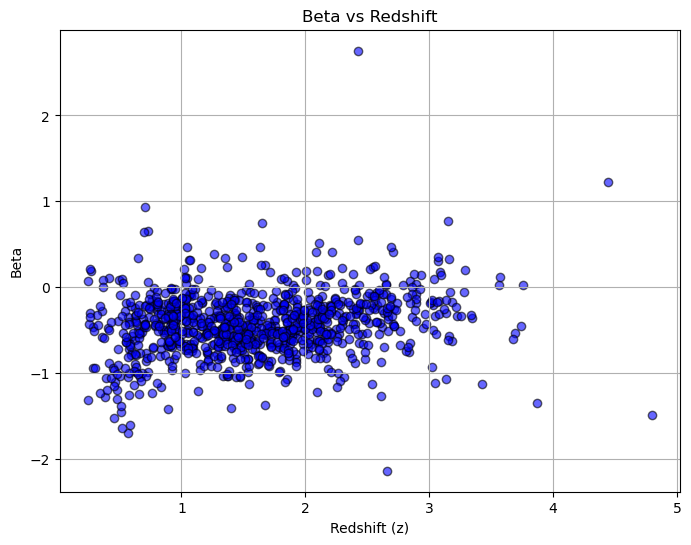

In [174]:
plt.figure(figsize=(8, 6))
plt.scatter(d['z'], d['beta'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('Beta')
plt.title('Beta vs Redshift')
plt.grid(True)
plt.show()

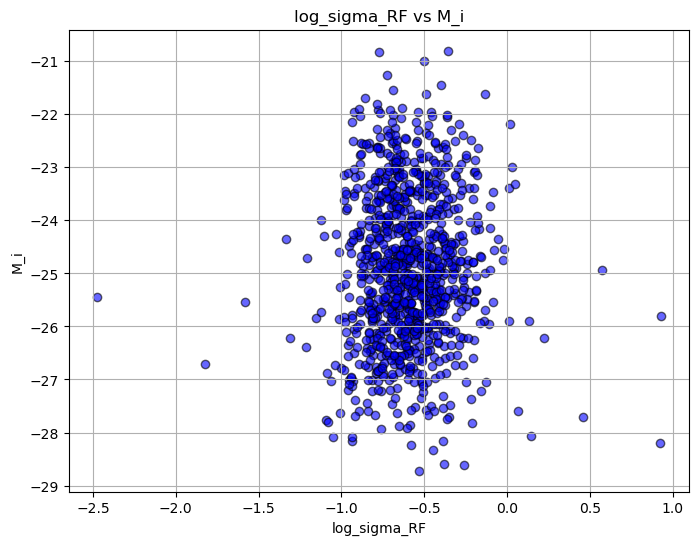

In [185]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'][df['M_i']<-15], df['M_i'][df['M_i']<-15], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log_sigma_RF')
plt.ylabel('M_i')
plt.title('log_sigma_RF vs M_i')
plt.grid(True)
plt.show()

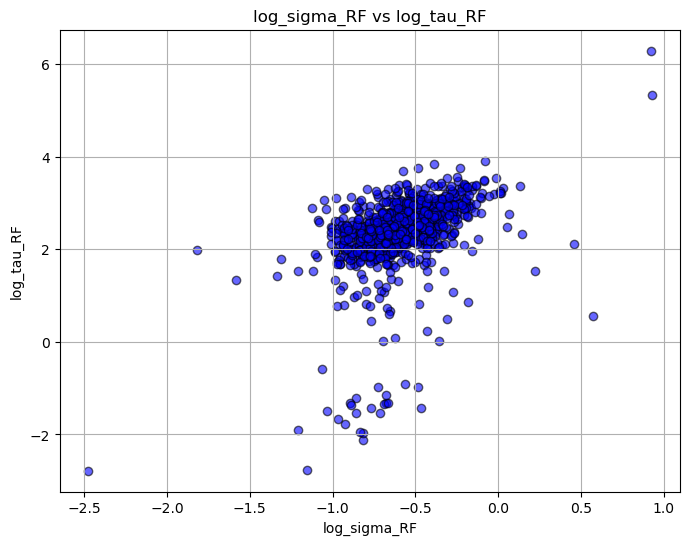

In [177]:
plt.figure(figsize=(8, 6))
plt.scatter(df['log_sigma_RF'], df['log_tau_RF'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log_sigma_RF')
plt.ylabel('log_tau_RF')
plt.title('log_sigma_RF vs log_tau_RF')
plt.grid(True)
plt.show()

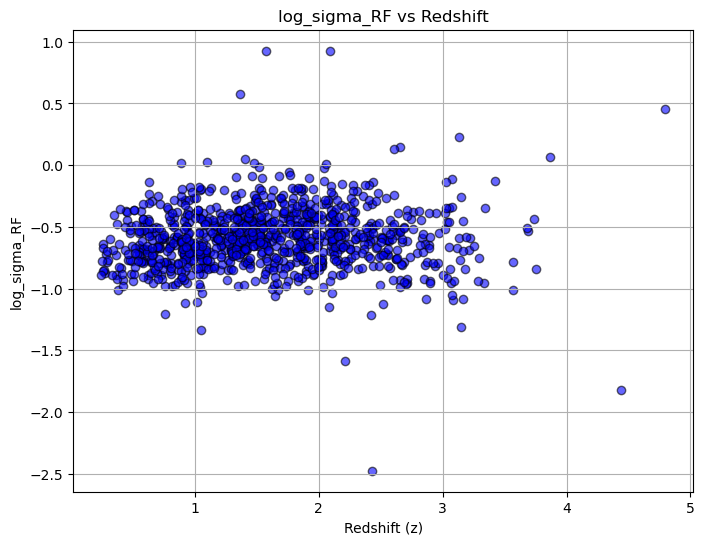

In [178]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['log_sigma_RF'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('log_sigma_RF')
plt.title('log_sigma_RF vs Redshift')
plt.grid(True)
plt.show()

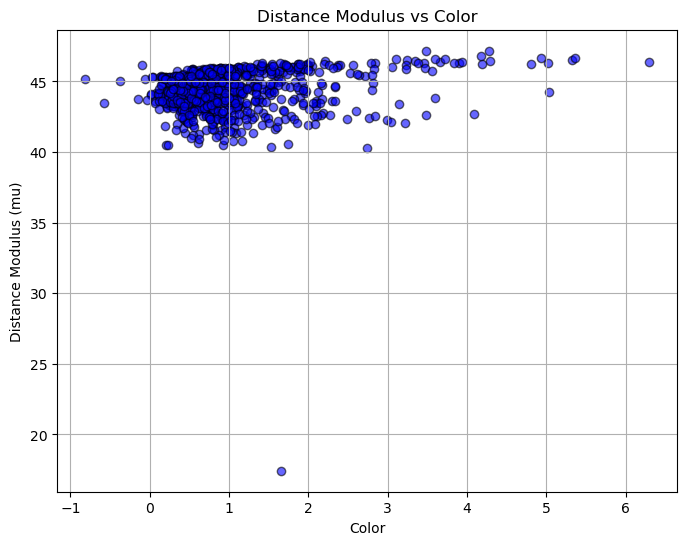

In [165]:
# Calculate the distance modulus
df['distance_modulus'] = df['apparent_mag_i'] - df['M_i']

# Plot distance modulus vs color
plt.figure(figsize=(8, 6))
plt.scatter(df['color'], df['distance_modulus'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('Color')
plt.ylabel('Distance Modulus (mu)')
plt.title('Distance Modulus vs Color')
plt.grid(True)
plt.show()

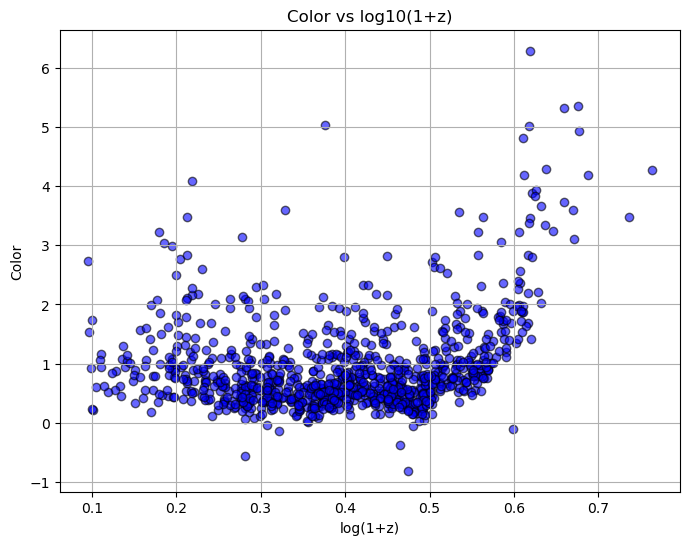

In [166]:
#df = df[df['color'] > -5]
plt.figure(figsize=(8, 6))
plt.scatter(np.log10(1 + df['z']), df['color'], c='blue', alpha=0.6, edgecolor='black')
plt.xlabel('log(1+z)')
plt.ylabel('Color')
plt.title('Color vs log10(1+z)')
plt.grid(True)
plt.show()

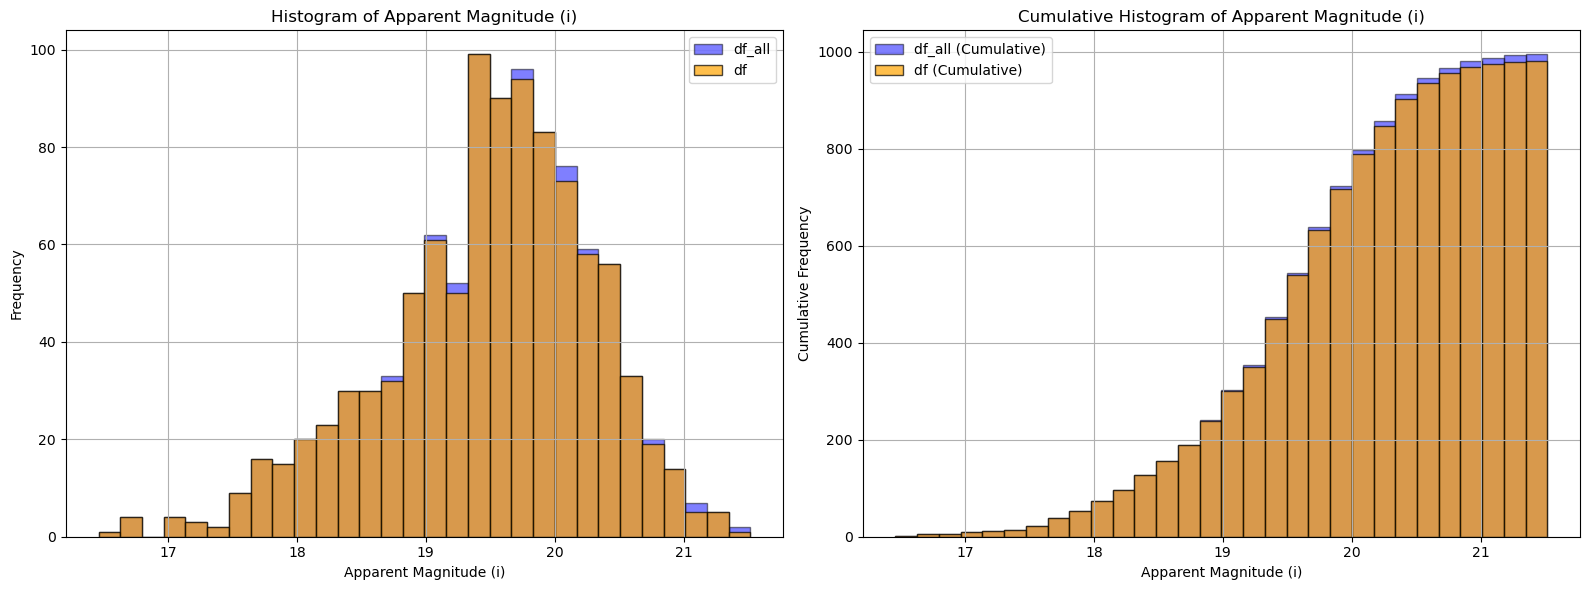

In [167]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot histogram for df_all
ax1.hist(df_all['apparent_mag_i'], bins=30, color='blue', alpha=0.5, label='df_all', edgecolor='black')
ax1.hist(df['apparent_mag_i'], bins=30, color='orange', alpha=0.7, label='df', edgecolor='black')
ax1.set_xlabel('Apparent Magnitude (i)')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram of Apparent Magnitude (i)')
ax1.legend()
ax1.grid(True)

# Plot cumulative histograms
ax2.hist(df_all['apparent_mag_i'], bins=30, color='blue', alpha=0.5, label='df_all (Cumulative)', edgecolor='black', cumulative=True) #, histtype='step')
ax2.hist(df['apparent_mag_i'], bins=30, color='orange', alpha=0.7, label='df (Cumulative)', edgecolor='black', cumulative=True) #, histtype='step')
ax2.set_xlabel('Apparent Magnitude (i)')
ax2.set_ylabel('Cumulative Frequency')
ax2.set_title('Cumulative Histogram of Apparent Magnitude (i)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

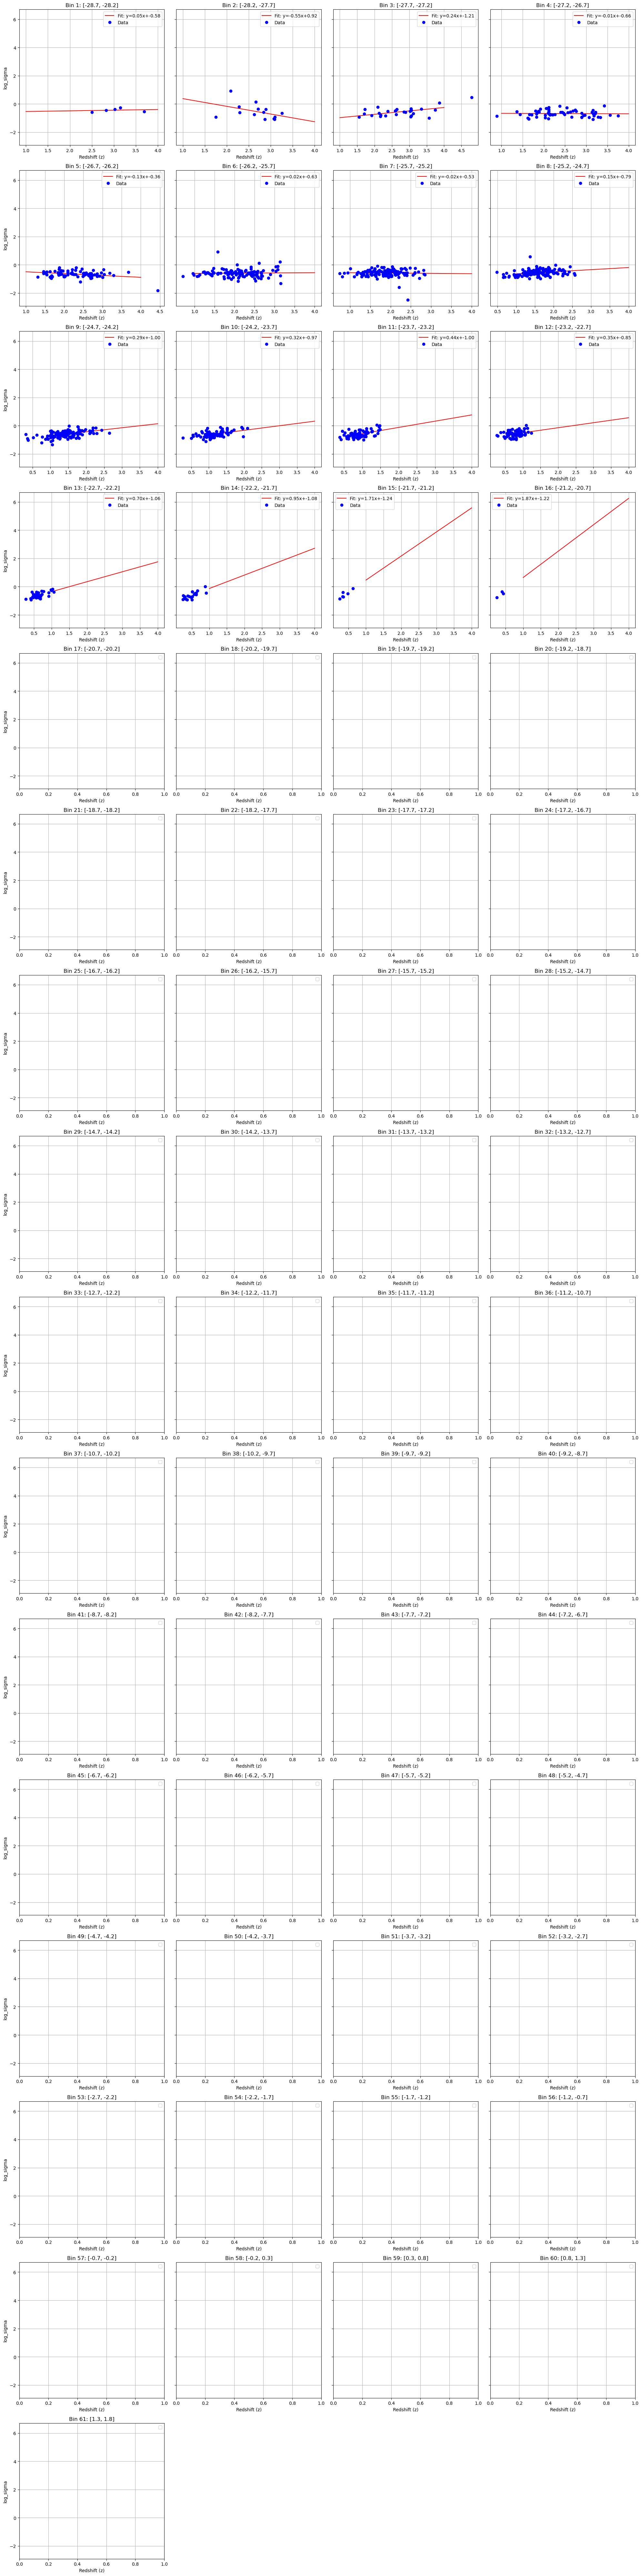

In [181]:
from scipy.stats import linregress

# Define the bins for M_i

M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_sigma_RF'])
        y_vals = slope * np.linspace(1, 4) + intercept
        axes[i].plot(np.linspace(1, 4), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_sigma_RF'], 'bo', label='Data')
        axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_sigma')
    axes[i].grid(True)
    axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

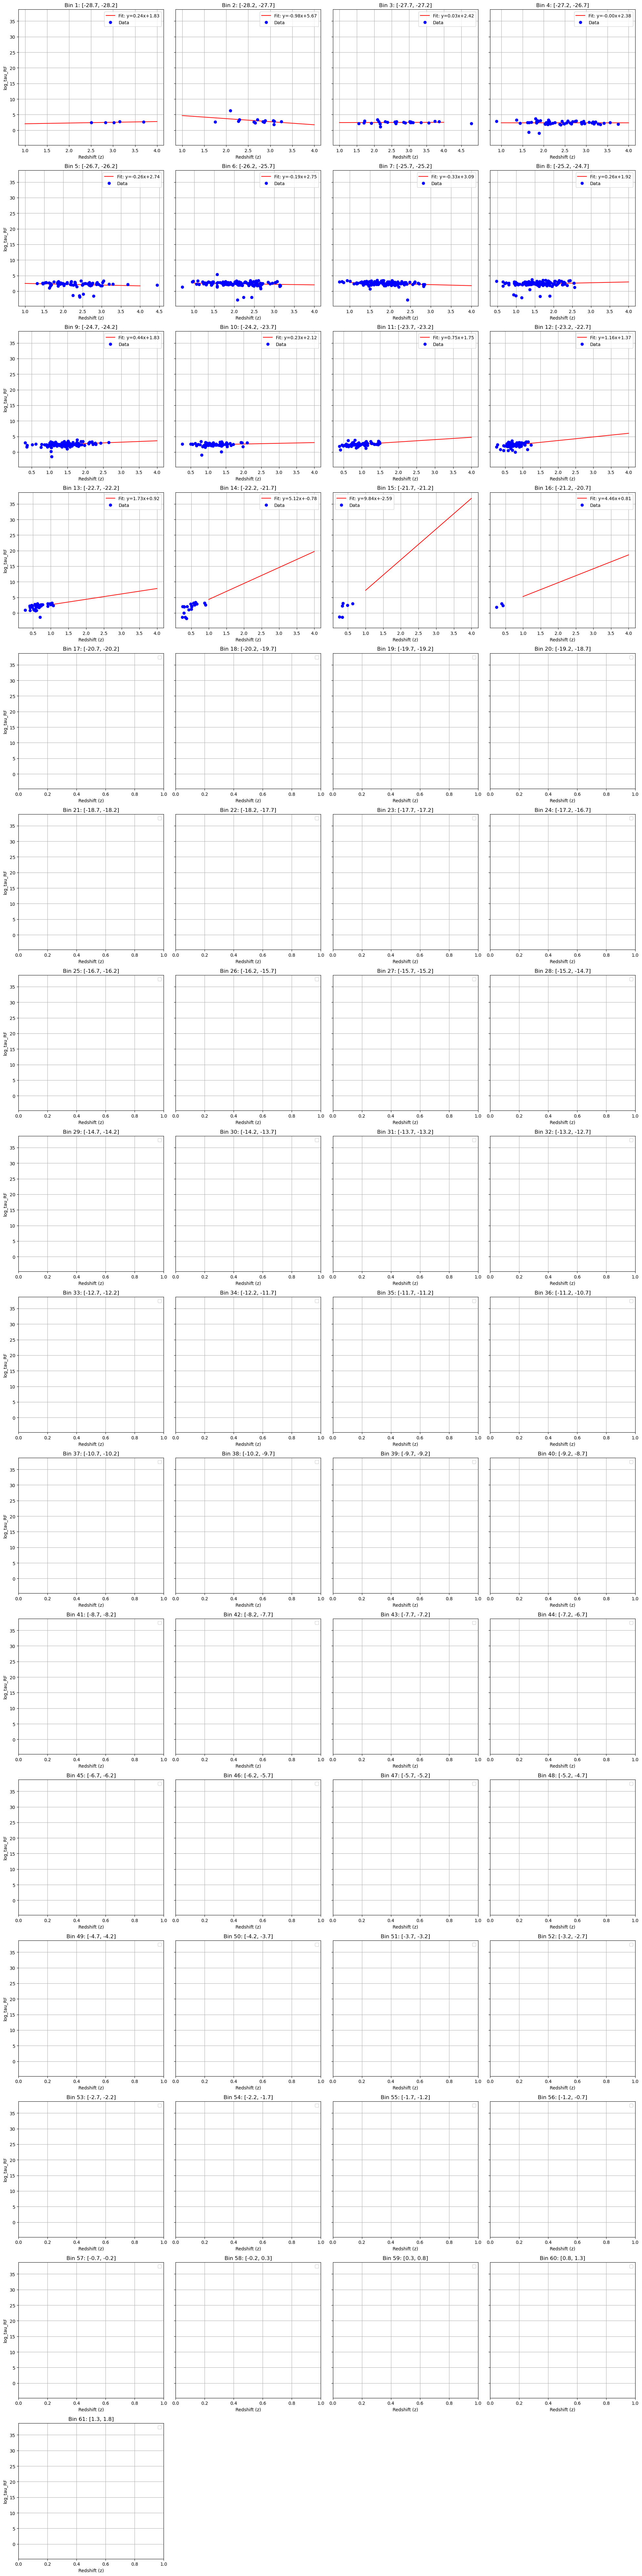

In [180]:
from scipy.stats import linregress

# Define the bins for M_i
M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_tau_RF'])
        y_vals = slope * np.linspace(1, 4) + intercept
        axes[i].plot(np.linspace(1, 4), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_tau_RF'], 'bo', label='Data')
        axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_tau_RF')
    axes[i].grid(True)
    axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

sample: 100%|██████████| 11000/11000 [00:06<00:00, 1741.45it/s, 15 steps of size 1.11e-01. acc. prob=0.96]


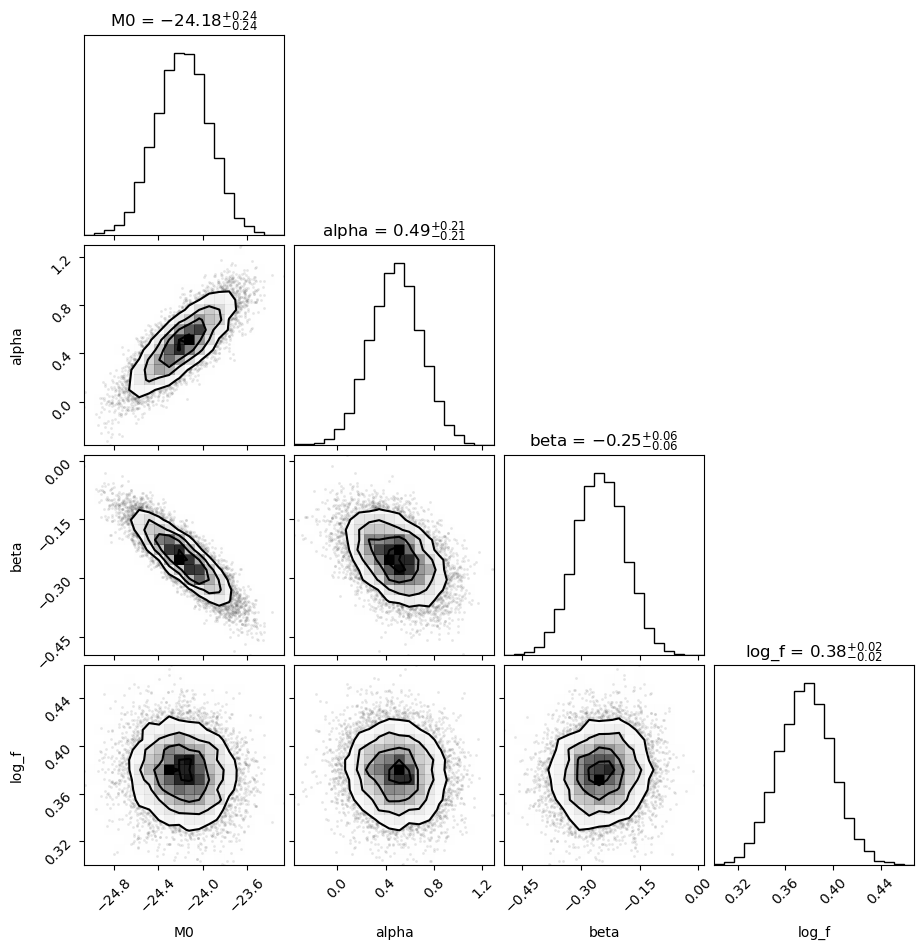

In [170]:
import numpyro
import jax
from numpyro.infer import MCMC, NUTS
from jax import vmap
import numpyro.distributions as dist


def M_model(alpha, beta, log_sigma_RF, log_tau_RF, M0, z):
    return M0 + alpha * log_sigma_RF + beta * log_tau_RF #+ gamma * color

def K_corr(z, alpha_nu=-0.5):
    return -2.5 * (1 + alpha_nu) * np.log10(1+z)

#flatcdm, nonflat cdm, nonflat and H changing w/ z CPL DSSMRL
# Define the model for sampling
def build_model(apparent_mag_i, apparent_mag_i_err, log_sigma_RF, log_tau_RF, log_lambda_RF, log_sigma_RF_err, log_tau_RF_err, z):

    alpha = numpyro.sample("alpha", dist.Uniform(-10, 10))
    beta = numpyro.sample("beta", dist.Uniform(-10, 10))
    M0 = numpyro.sample("M0", dist.Uniform(-100, 100))
    log_f = numpyro.sample("log_f", dist.Uniform(-5, 5))
    
    # Modify mu_pred and mu_pred_err to include K-correction
    mu_pred = apparent_mag_i - M_model(alpha, beta, log_sigma_RF, log_tau_RF, M0, z) - K_corr(z)
    mu_pred_err = jax.numpy.sqrt(apparent_mag_i_err**2 + (alpha * log_sigma_RF_err)**2 + (beta * log_tau_RF_err)**2 + jax.numpy.exp(2 * log_f))
    #mu_pred_err = jax.numpy.clip(mu_pred_err, a_min=1e-6, a_max=None)  # Ensure mu_pred_err is not too small

    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    mu_model = cosmo.distmod(z).value
    numpyro.sample("obs", dist.Normal(mu_model, mu_pred_err), obs=mu_pred)

# Run MCMC
mcmc = MCMC(NUTS(build_model), num_warmup=1000, num_samples=10000, num_chains=1)

# Test with subsamples
#d = df[df['z'].between(0,.6)]
#d = df[df['apparent_mag_i'] < 19]
d = df

mcmc.run(jax.random.PRNGKey(0), 
        d['apparent_mag_i'].to_numpy(), 
        d['apparent_mag_i_err'].to_numpy(), 
        d['log_sigma_RF'].to_numpy(), 
        d['log_tau_RF'].to_numpy(), 
        d['log_lambda_RF'].to_numpy(), 
        d['log_sigma_RF_err'].to_numpy(), 
        d['log_tau_RF_err'].to_numpy(), 
        d['z'].to_numpy())
samples = mcmc.get_samples(group_by_chain=False)

import corner
# Extract the posterior samples
posterior_samples = {
    "M0": samples["M0"],
    "alpha": samples["alpha"],
    "beta": samples["beta"],
    "log_f": samples["log_f"]
}

# Convert the samples to a 2D array for corner
data = np.vstack([posterior_samples[key] for key in posterior_samples.keys()]).T

# Create the corner plot
fig = corner.corner(data, labels=list(posterior_samples.keys()), show_titles=True)

100%|██████████| 1000/1000 [04:29<00:00,  3.71it/s]


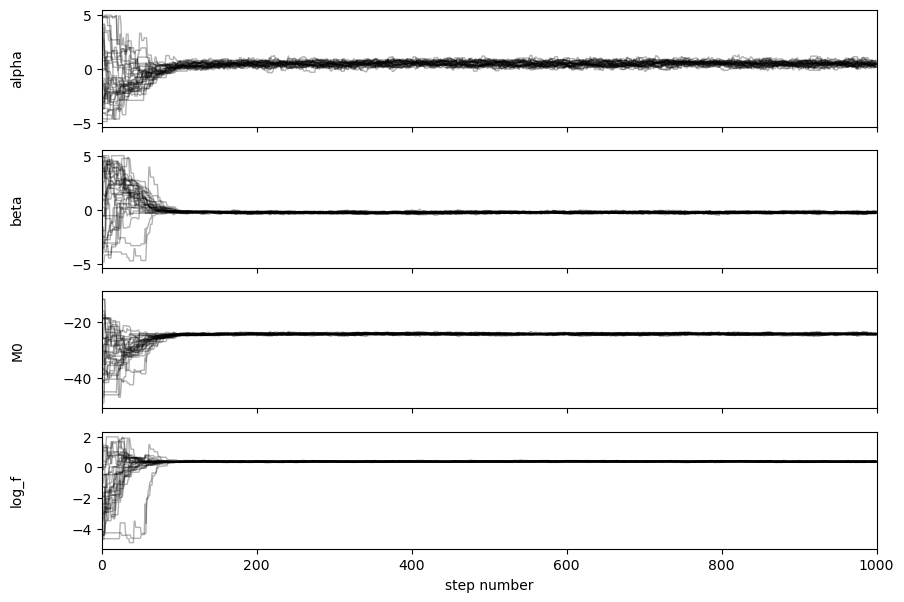

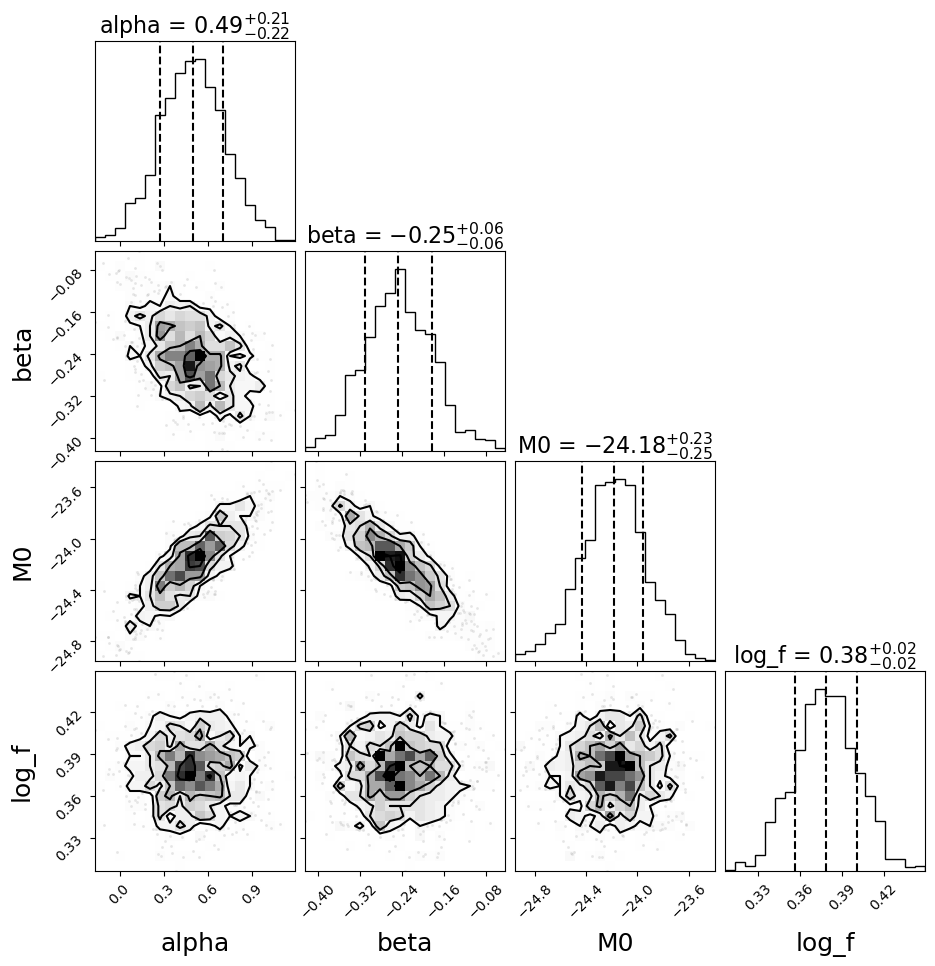

In [171]:
import emcee
import corner
import numpy as np
from astropy.cosmology import w0waCDM
import matplotlib.pyplot as plt

def M_model(M0, alpha, beta):
    return M0 + alpha * d["log_sigma_RF"] + beta * d["log_tau_RF"]

def K_corr(z, alpha_nu=-0.5):
    return -2.5 * (1 + alpha_nu) * np.log10(1 + z)

# log_likelihood function
def log_likelihood(theta):

    alpha, beta, M0, log_f = theta

    # Prior
    for i, (key, val) in enumerate(priors.items()):
        lower, upper = val
        if not (lower < theta[i] < upper):
            return -np.inf
    
    mu_pred = d['apparent_mag_i'] - M_model(M0, alpha, beta) - K_corr(d['z'])
    mu_pred_err = np.sqrt(d['apparent_mag_i_err']**2 + 
                          (alpha * d["log_sigma_RF_err"])**2 + 
                          (beta * d["log_tau_RF_err"])**2 + 
                          np.exp(2 * log_f))
    
    cosmo = w0waCDM(H0=70, Om0=0.3, Ode0=0.7, w0=-1, wa=0)
    mu_model = cosmo.distmod(d['z']).value

    return -0.5 * np.sum(((mu_pred - mu_model) / mu_pred_err)**2 + np.log(2 * np.pi * mu_pred_err**2))

# Define a dictionary to hold model parameters
priors = {
    "alpha": (-5, 5),
    "beta": (-5, 5),
    "M0": (-50, -10),
    "log_f": (-5, 2),
    # cosmology parameters
    #"H0": (50, 100),
    #"Om0": (0.1, 0.5),
    #"Omk": (-0.5, 0.5),
    #"Oml": (0.1, 0.9),
    #"w0": (-2, 2),
    #"wa": (-2, 2)
}

# Set up the sampler
ndim = len(priors)  # Number of parameters
nwalkers = 32  # Number of walkers
nsteps = 1000  # Number of steps

# Run the MCMC sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood)

# Initial positions of the walkers
initial_pos = np.array([np.random.uniform(low, high, nwalkers) for low, high in priors.values()]).T

sampler.run_mcmc(initial_pos, nsteps, progress=True)

# Extract the samples
samples_by_chain = sampler.get_chain()
#tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

labels = list(priors.keys())

fig, axes = plt.subplots(len(labels), figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_by_chain[:, :, i], "k", alpha=0.3, lw=1)
    ax.set_xlim(0, len(samples_by_chain))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.show()

fig = corner.corner(flat_samples, show_titles=True, labels=labels, quantiles=[0.16, 0.5, 0.84],
                    label_kwargs=dict(fontsize=18), title_kwargs=dict(fontsize=16));
plt.show()

results = {key: np.percentile(flat_samples[:, i], [16, 50, 84]) for i, key in enumerate(priors.keys())}

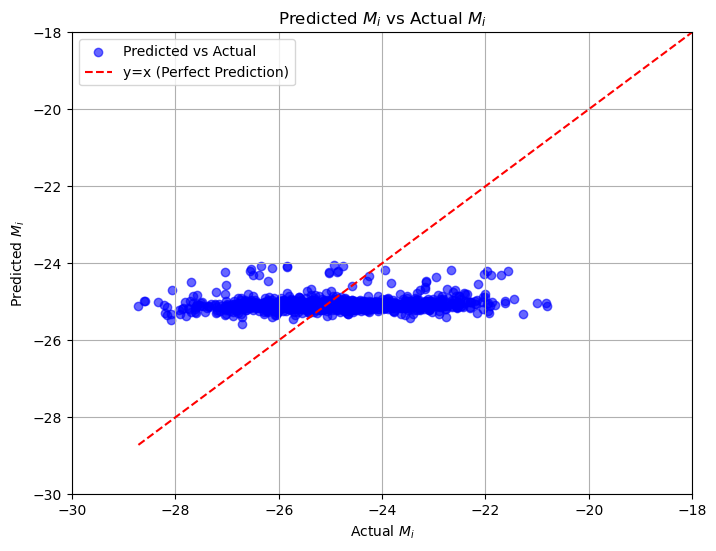

In [182]:
import matplotlib.pyplot as plt

# Assuming `predicted_M_i` contains the predicted M_i values
M_i_pred = M_model(
    results['M0'][1], 
    results['alpha'][1], 
    results['beta'][1]
)
# Extract actual M_i values from the dataframe
actual_M_i = df['M_i']

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(actual_M_i, M_i_pred, c='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([actual_M_i.min(), actual_M_i.max()], [actual_M_i.min(), actual_M_i.max()], 'r--', label='y=x (Perfect Prediction)')
plt.xlabel('Actual $M_i$')
plt.ylabel('Predicted $M_i$')
plt.title('Predicted $M_i$ vs Actual $M_i$')
plt.xlim(-30, -18)
plt.ylim(-30, -18)
plt.legend()
plt.grid(True)
plt.show()

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

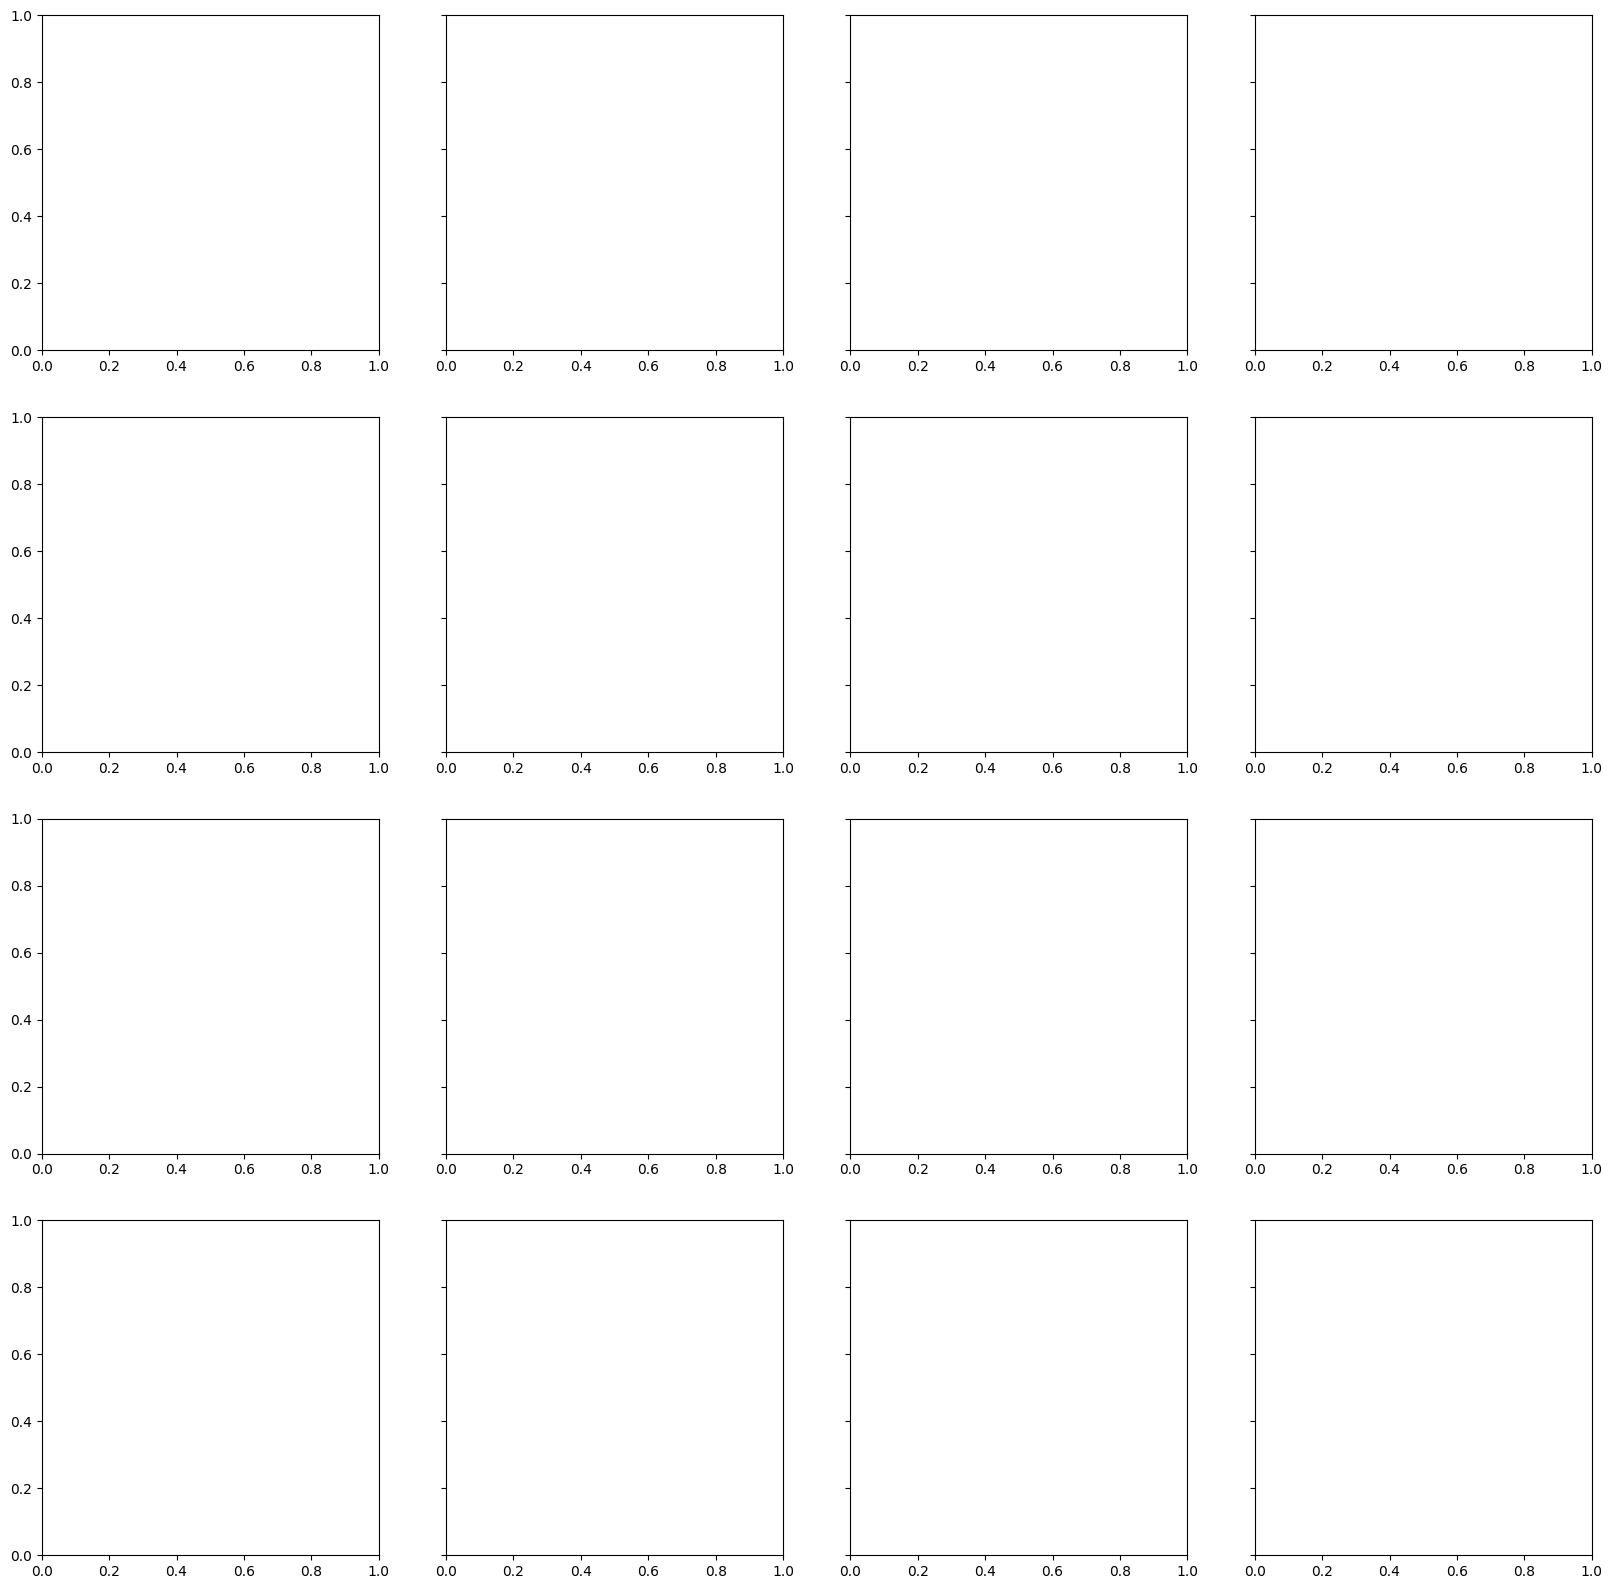

In [49]:
import matplotlib.pyplot as plt
# Define the bins for np.log10(1 + df['z'])
bins = np.arange(0, np.log10(1 + df['z']).max(), 0.05)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Iterate over each bin and plot
for i in range(len(bins) - 1):
    bin_mask = (np.log10(1 + df['z']) >= bins[i]) & (np.log10(1 + df['z']) < bins[i + 1])
    bin_data_actual = actual_M_i[bin_mask]
    bin_data_predicted = M_i_pred[bin_mask]
    
    axes[i].scatter(bin_data_actual, bin_data_predicted, c='blue', alpha=0.6, label='Predicted vs Actual')
    axes[i].plot([bin_data_actual.min(), bin_data_actual.max()], 
                 [bin_data_actual.min(), bin_data_actual.max()], 'r--', label='y=x (Perfect Prediction)')
    axes[i].set_title(f'Bin {i+1}: [{bins[i]:.2f}, {bins[i+1]:.2f}]')
    axes[i].set_xlabel('Actual $M_i$')
    if i == 0:
        axes[i].set_ylabel('Predicted $M_i$')
    axes[i].grid(True)
axes[i].legend()
    
plt.tight_layout()
plt.show()

In [19]:
url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon

/tmp/ipykernel_1351804/3507461940.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.88590,0.864470,0.0991,1.4960,0.0381,0.005,1.000,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.30640,0.812220,0.0971,1.4960,-0.0252,0.003,1.000,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.50000,0.000358,0.0399,0.7134,0.0545,0.019,1.000,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.12200,0.000193,0.0931,0.7134,0.0622,0.028,1.000,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.83900,0.988740,0.0567,0.6110,0.0650,0.009,1.000,0.006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696,rutledge,106,1.61505,0.00545,1.61499,0.00500,1.61399,0.00500,25.90650,0.331927,...,1.7256,8,2.92493,0.938980,0.2230,0.0106,-0.0203,0.005,1.000,0.002
1697,geta,106,1.69706,0.04006,1.69702,0.04000,1.70000,0.04000,26.03330,0.379521,...,1.8973,12,9.15387,0.689730,0.3209,0.0748,0.2680,0.005,0.633,0.000
1698,stone,106,1.80119,0.02014,1.80111,0.02000,1.80000,0.02000,26.23350,0.280685,...,1.1631,11,11.69320,0.387140,0.2370,0.0358,-0.0968,0.004,0.641,0.000
1699,wilson,106,1.91165,0.00263,1.91160,0.00100,1.91401,0.00100,26.17030,0.357624,...,1.4902,9,5.54378,0.784570,0.3168,0.0044,-0.3835,0.013,0.604,0.000


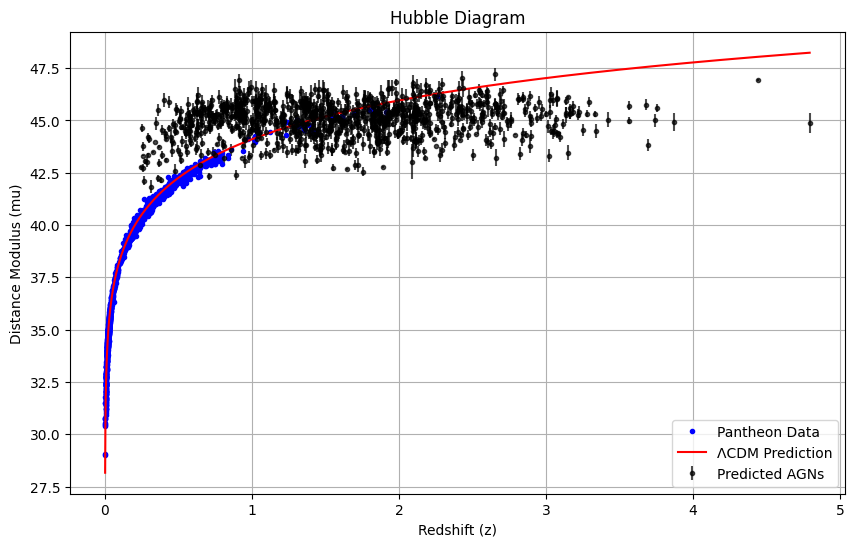

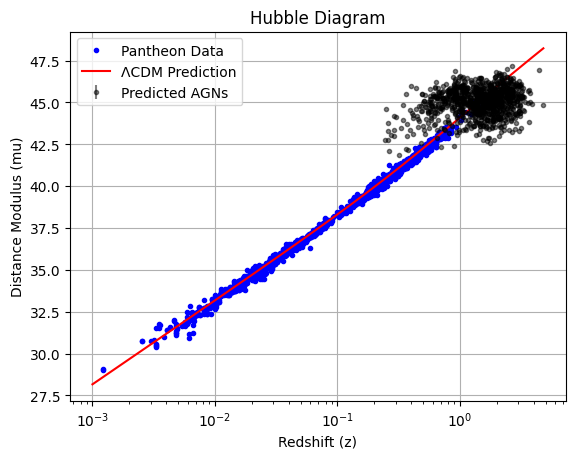

In [115]:


d = df

#d = df[df['apparent_mag_i'] < 19]

#mu_pred = d['apparent_mag_i'] - M_model(posterior_samples["alpha"], posterior_samples["beta"], posterior_samples["mu"], posterior_samples["nu"], d["color"], d["log_sigma_3"], d["log_tau_RF"], posterior_samples["M0"], d["z"]) - K_corr(d["z"])
#mu_pred_median = np.percentile(mu_pred, 50, axis=0)
mu_pred_median = d['apparent_mag_i'] - M_model(np.median(posterior_samples["alpha"]), np.median(posterior_samples["beta"]), d["log_sigma_RF"], d["log_tau_RF"], np.median(posterior_samples["M0"]), d["z"]) - K_corr(d["z"])
mu_pred_16th = d['apparent_mag_i'] - M_model(np.percentile(posterior_samples["alpha"], 16), np.percentile(posterior_samples["beta"], 16), d["log_sigma_RF"], d["log_tau_RF"], np.percentile(posterior_samples["M0"], 16), d["z"]) - K_corr(d["z"])
mu_pred_84th = d['apparent_mag_i'] - M_model(np.percentile(posterior_samples["alpha"], 84), np.percentile(posterior_samples["beta"], 84), d["log_sigma_RF"], d["log_tau_RF"], np.percentile(posterior_samples["M0"], 84), d["z"]) - K_corr(d["z"])
mu_pred_std = np.abs(0.5 * (mu_pred_84th - mu_pred_16th))

plt.figure(figsize=(10, 6))
#plt.errorbar(d["z"], mu, yerr=dmu, fmt='o', label="Observed AGNs", alpha=0.5, color="blue")
plt.errorbar(d["z"], mu_pred_median, yerr=mu_pred_std, fmt='.', label="Predicted AGNs", alpha=0.7, color="black")
plt.plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")


z_grid = np.geomspace(0.001, d['z'].max(), 1000)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
plt.plot(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.title("Hubble Diagram")
plt.legend()
plt.grid(True)
plt.show()

plt.errorbar(d["z"], mu_pred_median, yerr=0, fmt='.', label="Predicted AGNs", alpha=0.5, color="k")
plt.plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")
plt.semilogx(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.title("Hubble Diagram")
plt.legend()
plt.grid(True)
plt.show()

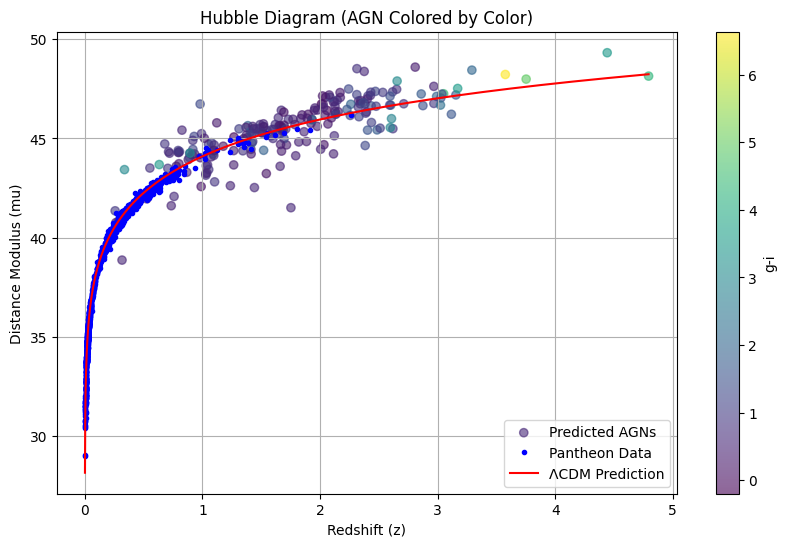

In [25]:
plt.figure(figsize=(10, 6))

# Plot AGNs with color-coded points
plt.scatter(d["z"], mu_pred_median, c=d["color"], cmap="viridis", alpha=0.6, label="Predicted AGNs")
plt.colorbar(label="g-i")

# Plot Pantheon data
plt.plot(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], 'b.', label="Pantheon Data")

# Plot ΛCDM prediction
z_grid = np.geomspace(0.001, d['z'].max(), 1000)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
plt.plot(z_grid, cosmo.distmod(z_grid).value, label="ΛCDM Prediction", color="red")

plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
plt.title("Hubble Diagram (AGN Colored by Color)")
plt.legend()
plt.grid(True)
plt.show()